### Passo 1 - Importar Arquivos e Bibliotecas


### Indicadores do OnePage

- Faturamento -> Meta Ano: 1.650.000 / Meta Dia: 1000
- Diversidade de Produtos (quantos produtos diferentes foram vendidos naquele período) -> Meta Ano: 120 / Meta Dia: 4
- Ticket Médio por Venda -> Meta Ano: 500 / Meta Dia: 500

In [ ]:
import pandas as pd
import smtplib
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.base import MIMEBase
from email import encoders
import pathlib 

# metas 
meta_fat_ano = 1650000
meta_fat_dia = 1000
meta_div_ano = 120
meta_div_dia = 4
meta_ticket_ano = 500 
meta_ticket_dia = 500

# leitura das bases de dados
vendas = pd.read_excel("Bases de Dados/Vendas.xlsx")
lojas = pd.read_csv("Bases de Dados/Lojas.csv", encoding="latin1", sep=";")
emails = pd.read_excel("Bases de Dados/Emails.xlsx")

# mesclagem de tabelas (vendas com lojas)
vendas = vendas.merge(lojas, left_on= "ID Loja", right_on="ID Loja")

### Passo 2 - Definir Criar uma Tabela para cada Loja e Definir o dia do Indicador

In [ ]:
dict_lojas = {}
for loja in lojas["Loja"]:
    dict_lojas[loja] = vendas.loc[vendas["Loja"] == loja]

indicador_dia = vendas["Data"].max() #pega a última data da base de vendas e define o indicador do dia

# print(indicador_dia)
# print(dict_lojas["Shopping Center Interlagos"])


### Passo 3 - Salvar a planilha na pasta de backup

In [ ]:
caminho = pathlib.Path(r"C:/Users/Admin/Desktop/Projeto 1- Automação de processos/Backup Arquivos Lojas")
arquivos_pasta = caminho.iterdir()
lista_nomes_backup = [arquivo.name for arquivo in arquivos_pasta]

for loja in dict_lojas: 
    if loja not in lista_nomes_backup: 
        nova_pasta = caminho / loja
        nova_pasta.mkdir()
    nome_arquivo = f"{indicador_dia.month}_{indicador_dia.day}_{loja}.xlsx"
    local_arquivo = caminho / loja / nome_arquivo
    dict_lojas[loja].to_excel(local_arquivo)

### Passo 4 / 5 / 6- Calcular os indicadores, comparação dinâmica de resultados e envio de e-mails para os gerentes

In [ ]:
for loja in dict_lojas:
    vendas_loja = dict_lojas[loja]
    vendas_loja_dia = vendas_loja.loc[vendas["Data"] == indicador_dia]

    # faturamento geral e do dia definido do indicador
    faturamento_loja_ano = float(vendas_loja["Valor Final"].sum())
    faturamento_loja_dia = float(vendas_loja_dia["Valor Final"].sum())

    # diversidade de produtos geral e do dia do indicador
    qt_produtos_ano = len(vendas_loja["Produto"].unique())
    qt_produtos_dia = len(vendas_loja_dia["Produto"].unique())

    # ticket médio do ano e do dia do indicador
    valor_venda_ano = vendas_loja.groupby("Código Venda").sum(True)
    ticket_medio_ano = float(valor_venda_ano["Valor Final"].mean())
    valor_venda_dia = vendas_loja_dia.groupby("Código Venda").sum(True)
    ticket_medio_dia = float(valor_venda_dia["Valor Final"].mean())

    # icones e comparação para as metas diárias
    bola_fat_dia = '🟢' if faturamento_loja_dia >= meta_fat_dia else '🔴'
    bola_div_dia = '🟢' if qt_produtos_dia >= meta_div_dia else '🔴'
    bola_ticket_dia = '🟢' if ticket_medio_dia >= meta_ticket_dia else '🔴'
    # icones e comparação para as metas anuais
    bola_fat_ano = '🟢' if faturamento_loja_ano >= meta_fat_ano else '🔴'
    bola_div_ano = '🟢' if qt_produtos_ano >= meta_div_ano else '🔴'
    bola_ticket_ano = '🟢' if ticket_medio_ano >= meta_ticket_ano else '🔴'

    # CONFIGURAÇÕES DE LOGIN (Preencha com seus dados de remetente)
    meu_email = "rodrigoluan30@gmail.com"
    minha_senha = "dmwo etad oled psrb"
    # Configurações do e-mail de destino
    nome = emails.loc[emails["Loja"] == loja, "Gerente"].values[0] # procura o gerente responsável pela loja 
    email_to = emails.loc[emails["Gerente"] == nome, "E-mail"].values[0]

    # Cria o objeto da mensagem SMTP
    msg = MIMEMultipart()
    msg['From'] = meu_email
    msg['To'] = email_to
    msg['Subject'] = f"OnePage Dia {indicador_dia.day}/{indicador_dia.month}/{indicador_dia.year} - Loja {loja}"

    # Conteúdo HTMLBody original mantido idêntico
    html_body = f"""
    <p>Bom dia, {nome}</p>
    <br> 
    Segue os resultados de ontem <strong>({indicador_dia.day}/{indicador_dia.month})</strong> da <strong> loja
    {loja}</strong>:
    <br>
    <table>
    <tr >
        <th ></th>
        <th style="text-align: center;">Valor dia</th>
        <th style="text-align: center;">Meta dia</th>
        <th style="text-align: center;">Cenário dia</th>
    </tr>
    <tr>
        <td style="text-align: center;">Faturamento</td>
        <td  style="text-align: center;">R$ {faturamento_loja_dia:.2f}</td>
        <td  style="text-align: center;">R$ {meta_fat_dia:.2f}</td>
        <td style="text-align: center;"><span style="color:red;">{str(bola_fat_dia)}</span></td>
    </tr>
    <tr>
        <td style="text-align: center;">Diversidade de Produtos</td>
        <td style="text-align: center;">{qt_produtos_dia}</td>
        <td style="text-align: center;">{meta_div_dia}</td>
        <td style="text-align: center;"><span style="color:red;">{str(bola_div_dia)}</span></td>
    </tr>
    <tr>
        <td style="text-align: center;">Ticket Médio</td>
        <td style="text-align: center;">R$ {ticket_medio_dia:.2f}</td>
        <td style="text-align: center;">R$ {meta_ticket_dia:.2f}</td>
        <td style="text-align: center;"><span style="color:red;">{str(bola_ticket_dia)}</span></td>
    </tr>
    </table>
    <br>
    <table>
    <tr >
        <th ></th>
        <th style="text-align: center;">Valor ano</th>
        <th style="text-align: center;">Meta ano</th>
        <th style="text-align: center;">Cenário ano</th>
    </tr>
    <tr>
        <td style="text-align: center;">Faturamento</td>
        <td  style="text-align: center;">R$ {faturamento_loja_ano:.2f}</td>
        <td  style="text-align: center;">R$ {meta_fat_ano:.2f}</td>
        <td style="text-align: center;"><span style="color:red;">{str(bola_fat_ano)}</span></td>
    </tr>
    <tr>
        <td style="text-align: center;">Diversidade de Produtos</td>
        <td style="text-align: center;">{qt_produtos_ano}</td>
        <td style="text-align: center;">{meta_div_ano}</td>
        <td style="text-align: center;"><span style="color:red;">{str(bola_div_ano)}</span></td>
    </tr>
    <tr>
        <td style="text-align: center;">Ticket Médio</td>
        <td style="text-align: center;">R$ {ticket_medio_ano:.2f}</td>
        <td style="text-align: center;">R$ {meta_ticket_ano:.2f}</td>
        <td style="text-align: center;"><span style="color:red;">{str(bola_ticket_ano)}</span></td>
    </tr>
    </table>
    <br>  
    <p>Segue em anexo a planilha com todos os dados para mais detalhes. Qualquer dúvida estou à disposição.</p>
    <p>Att,</p>
    <p>Luan</p> 
    """

    # Associa o corpo HTML à mensagem
    msg.attach(MIMEText(html_body, 'html'))

    # Para anexar um arquivo (Lógica original adaptada para ler os bytes do arquivo)
    caminho_arquivo = caminho / loja / f"{indicador_dia.month}_{indicador_dia.day}_{loja}.xlsx"
    with open(caminho_arquivo, "rb") as anexo:
        part = MIMEBase("application", "octet-stream")
        part.set_payload(anexo.read())
        encoders.encode_base64(part)
        part.add_header("Content-Disposition", f"attachment; filename={caminho_arquivo.name}")
        msg.attach(part)

    # Conecta ao servidor SMTP do GMAIL e envia de forma direta
    server = smtplib.SMTP('smtp.gmail.com', 587)
    server.starttls()
    server.login(meu_email, minha_senha)
    server.sendmail(meu_email, email_to, msg.as_string())
    server.quit()

    print("E-mail enviado com sucesso!")


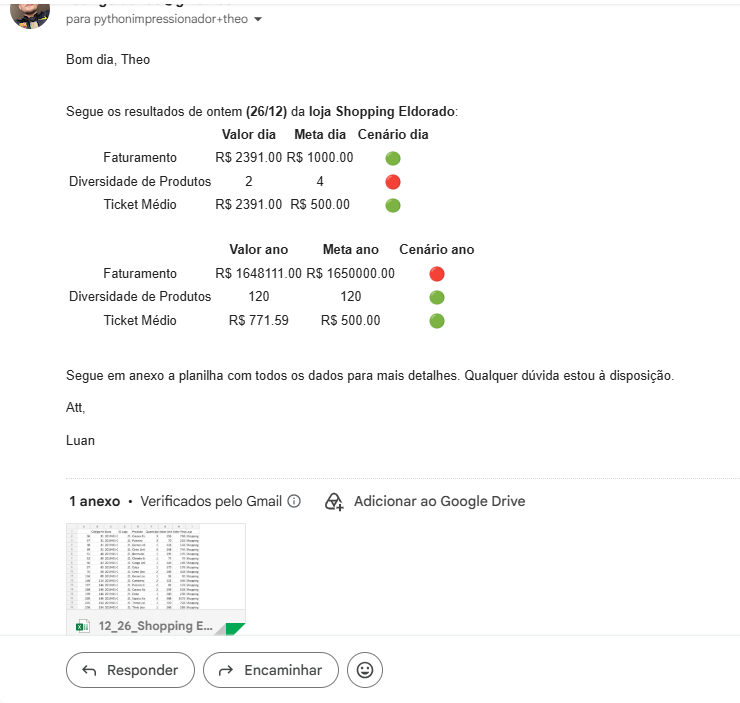

### Passo 7 - Criar ranking para diretoria

In [125]:
#agrupamento por loja da base geral anual, somando o valor final e deixando os maiores por primeiro
faturamento_lojas = vendas.groupby("Loja",)[["Loja", "Valor Final"]].sum(True)
ranking_anual = faturamento_lojas.sort_values(by="Valor Final", ascending=False)

# criação da planilha com os valores anuais
nome_arquivo = f"{indicador_dia.month}_{indicador_dia.day}_Ranking Anual.xlsx"
ranking_anual.to_excel(fr"Backup Arquivos Lojas/{nome_arquivo}")

# definição de base das vendas do dia, depois agrupamento dos valores finais por loja e ordenamento dos maiores primeiro
vendas_dia = vendas.loc[vendas["Data"] == indicador_dia]
faturamento_lojas_dia = vendas_dia.groupby("Loja")[["Loja", "Valor Final"]].sum(True)
ranking_diario = faturamento_lojas_dia.sort_values(by= "Valor Final", ascending= False)

# criação da planilha com os valores diários
nome_arquivo = f"{indicador_dia.month}_{indicador_dia.day}_Ranking Diário.xlsx"
ranking_diario.to_excel(fr"Backup Arquivos Lojas/{nome_arquivo}")


In [ ]:
display(ranking_anual)
display(ranking_anual[])

,Valor Final
Loja,
Iguatemi Campinas,1762419
Shopping Vila Velha,1731167
Bourbon Shopping SP,1726110
Rio Mar Recife,1722766
Shopping SP Market,1721763
Palladium Shopping Curitiba,1721120
Norte Shopping,1711968
Ribeirão Shopping,1707122
Iguatemi Esplanada,1699681


np.int64(1731167)

### Passo 8 - Enviar e-mail para diretoria

In [129]:
meu_email = "rodrigoluan30@gmail.com"
minha_senha = "dmwo etad oled psrb"

# Configurações do e-mail de destino 
email_to = emails.loc[emails["Gerente"] == "Diretoria", "E-mail"].values[0]

# Cria o objeto da mensagem SMTP
msg = MIMEMultipart()
msg['From'] = meu_email
msg['To'] = email_to
msg['Subject'] = f"Ranking Dia {indicador_dia.day}/{indicador_dia.month}/{indicador_dia.year}"

# Conteúdo HTMLBody original mantido idêntico
html_body = f"""
<p>Olá, prezados!</p> 

<p>Melhor loja do dia em faturamento: Loja {ranking_diario.index[0]} com faturamento R$ {ranking_diario.iloc[0, 0]:.2f}</p>
<p>Pior loja do dia em faturamento: Loja {ranking_diario.index[-1]} com faturamento R$ {ranking_diario.iloc[-1, 0]:.2f}</p>
<p>Melhor loja do ano em faturamento: Loja {ranking_anual.index[0]} com faturamento R$ {ranking_anual.iloc[0, 0]:.2f}</p>
<p>Pior loja do ano em faturamento: Loja {ranking_anual.index[-1]} com faturamento R$ {ranking_anual.iloc[-1, 0]:.2f}</p>

<p>Segue em anexo os rankings do ano e do dia de cada uma das lojas.</p>
<p>Fico à disposição em caso de dúvidas.</p>

<p>Att, 
Luan</p>
"""
# Associa o corpo HTML à mensagem
msg.attach(MIMEText(html_body, 'html'))

# Para anexar um arquivo (Lógica original adaptada para ler os bytes do arquivo)
# --- ANEXO 1: Ranking Anual ---
caminho_anual = caminho / f"{indicador_dia.month}_{indicador_dia.day}_Ranking Anual.xlsx"
with open(caminho_anual, "rb") as anexo_anual:
    part1 = MIMEBase("application", "octet-stream")
    part1.set_payload(anexo_anual.read())
    encoders.encode_base64(part1)
    # CORREÇÃO: Passar o filename como parâmetro direto protege o nome do arquivo
    part1.add_header("Content-Disposition", "attachment", filename=caminho_anual.name)
    msg.attach(part1)

# --- ANEXO 2: Ranking Diário ---
caminho_diario = caminho / f"{indicador_dia.month}_{indicador_dia.day}_Ranking Diário.xlsx"
with open(caminho_diario, "rb") as anexo_diario:
    part2 = MIMEBase("application", "octet-stream")
    part2.set_payload(anexo_diario.read())
    encoders.encode_base64(part2)
    # CORREÇÃO: Protege o caractere especial "í" de quebrar o envio no Gmail
    part2.add_header("Content-Disposition", "attachment", filename=caminho_diario.name)
    msg.attach(part2)


# Conecta ao servidor SMTP do GMAIL e envia de forma direta
server = smtplib.SMTP('smtp.gmail.com', 587)
server.starttls()
server.login(meu_email, minha_senha)
server.sendmail(meu_email, email_to, msg.as_string())
server.quit()

print("Email da diretoria enviado")

Email da diretoria enviado


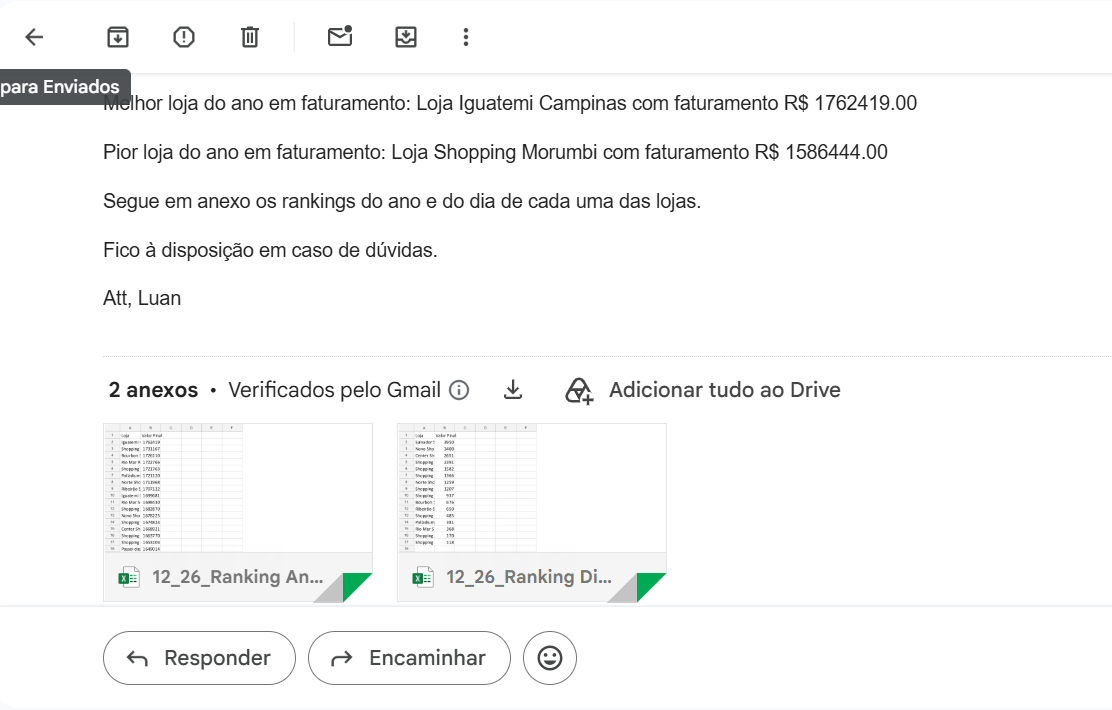